<a href="https://colab.research.google.com/github/soloimsad/literatura/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto dental CNN: segmentacion y rotulado de radiografias panoramicas

Notebook academico para entrenar una CNN tipo U-Net sobre radiografias dentales. El flujo implementa:

1. Descarga de datasets publicos desde Kaggle.
2. Lectura de anotaciones tipo Roboflow CSV o COCO JSON.
3. Construccion de pseudo-mascaras refinadas desde bounding boxes usando informacion de la imagen.
4. Entrenamiento de una U-Net 2D en PyTorch.
5. Evaluacion con Dice e IoU.
6. Prediccion sobre una radiografia y salida rotulada con mascaras, contornos, cajas y etiquetas.

Nota metodologica: cuando el dataset entrega cajas y no mascaras manuales pixel-perfect, las cajas se usan como supervision inicial y se refinan dentro de cada region de interes mediante contraste local, umbralizacion adaptativa, morfologia y filtrado por componentes. El objetivo es tratar la segmentacion con rigor dentro de las restricciones reales del dataset. Para una validacion clinica definitiva se requeririan mascaras manuales revisadas por especialistas; en este notebook se reportan metricas contra las pseudo-mascaras refinadas y se separa claramente inferencia academica de diagnostico clinico.

In [1]:
!pip -q install kagglehub pandas pillow opencv-python tqdm scikit-learn matplotlib

from dataclasses import dataclass
from pathlib import Path
import json
import random
import shutil
import time
from typing import Iterable

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Cambia esto a False si no quieres montar Google Drive.
USE_DRIVE = True
try:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        RUN_DIR = Path("/content/drive/MyDrive/dental_cnn_runs")
    else:
        RUN_DIR = Path("/content/dental_cnn_runs")
except Exception as exc:
    print("No se pudo montar Drive; usando /content. Detalle:", exc)
    RUN_DIR = Path("/content/dental_cnn_runs")

DATA_DIR = Path("/content/dental_datasets")
RUN_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("RUN_DIR:", RUN_DIR)
print("DATA_DIR:", DATA_DIR)

Device: cuda
GPU: Tesla T4
No se pudo montar Drive; usando /content. Detalle: mount failed
RUN_DIR: /content/dental_cnn_runs
DATA_DIR: /content/dental_datasets


In [2]:
import kagglehub

DATASET_SLUGS = [
    "imtkaggleteam/dental-radiography",
    "lokisilvres/dental-disease-panoramic-detection-dataset",
]

def download_kaggle_datasets(slugs: list[str]) -> list[Path]:
    roots = []
    for slug in slugs:
        print(f"Descargando/verificando: {slug}")
        path = Path(kagglehub.dataset_download(slug))
        roots.append(path)
        print("  ->", path)
    return roots

DATASET_ROOTS = download_kaggle_datasets(DATASET_SLUGS)

def preview_tree(root: Path, max_items: int = 40) -> None:
    print(f"\nArbol parcial: {root}")
    count = 0
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        print("  ", rel)
        count += 1
        if count >= max_items:
            print("  ...")
            break

for root in DATASET_ROOTS:
    preview_tree(root, max_items=35)

Descargando/verificando: imtkaggleteam/dental-radiography


100%|██████████| 18.5M/18.5M [00:01<00:00, 18.4MB/s]

Extracting files...


  -> /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1
Descargando/verificando: lokisilvres/dental-disease-panoramic-detection-dataset


100%|██████████| 2.37G/2.37G [00:59<00:00, 42.8MB/s]

Extracting files...


  -> /root/.cache/kagglehub/datasets/lokisilvres/dental-disease-panoramic-detection-dataset/versions/6

Arbol parcial: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1
   test
   test/0004_jpg.rf.6434bfce7667ea786e5f251dc0d8b8b1.jpg
   test/0007_jpg.rf.3699155bba57d7aecb1aa801a698ba20.jpg
   test/0009_jpg.rf.957a0a16c5101765b0679e95eb9619a3.jpg
   test/0038_jpg.rf.e13603a0be37e61c53a3b781040ce9f7.jpg
   test/0053_jpg.rf.0a39e4969cb730a0e08d415d819e14d9.jpg
   test/0060_jpg.rf.f094ea29e65bf0c78188acbcbc5c8dcd.jpg
   test/0061_jpg.rf.3188dc5179f4b6d600459b1aeba93e87.jpg
   test/0074_jpg.rf.bc31f3d89ccb17453e7558a14bd6d5de.jpg
   test/0081_jpg.rf.b8e53bd80056c633065450a6800872b2.jpg
   test/0095_jpg.rf.d7773e0afb13f54a3e6244079b483ab2.jpg
   test/0128_jpg.rf.717cd6a69102c36ff5b84b4a87c5a210.jpg
   test/0129_jpg.rf.aa992cd69694d8acea8ae20613465d94.jpg
   test/0136_jpg.rf.03e2aec8ec77594665dd1abc68d47bd3.jpg
   test/0139_jpg.rf.d4cd5163c13152c77c8982cf80a17a84.jpg

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
SPLIT_ALIASES = {
    "train": {"train", "training"},
    "valid": {"valid", "val", "validation"},
    "test": {"test", "testing"},
}

@dataclass(frozen=True)
class AnnotationBox:
    class_name: str
    x1: float
    y1: float
    x2: float
    y2: float

@dataclass(frozen=True)
class ImageRecord:
    image_path: Path
    width: int
    height: int
    boxes: tuple[AnnotationBox, ...]
    source: str

def normalize_class_name(name: str) -> str:
    cleaned = " ".join(str(name).replace("_", " ").replace("-", " ").split()).strip()
    aliases = {
        "Cavity": "Caries",
        "cavity": "Caries",
        "Fillings": "Filling",
        "croen": "Crown",
        "Impacted Tooth": "Impacted tooth",
    }
    return aliases.get(cleaned, cleaned or "Object")

def path_matches_split(path: Path, split: str) -> bool:
    aliases = SPLIT_ALIASES.get(split, {split})
    parts = {part.lower() for part in path.parts}
    name = path.name.lower()
    return bool(parts & aliases) or any(alias in name for alias in aliases)

def build_image_index(root: Path) -> dict[str, list[Path]]:
    index: dict[str, list[Path]] = {}
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            index.setdefault(path.name, []).append(path)
    return index

def find_image_path(filename: str, base_dir: Path, image_index: dict[str, list[Path]], split: str) -> Path | None:
    direct = base_dir / filename
    if direct.exists():
        return direct
    candidates = image_index.get(Path(filename).name, [])
    split_candidates = [p for p in candidates if path_matches_split(p, split)]
    if split_candidates:
        return split_candidates[0]
    return candidates[0] if candidates else None

def load_roboflow_csv_records(root: Path, split: str) -> list[ImageRecord]:
    records: list[ImageRecord] = []
    image_index = build_image_index(root)
    csv_paths = [p for p in root.rglob("_annotations.csv") if path_matches_split(p, split)]

    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)
        required = {"filename", "width", "height", "class", "xmin", "ymin", "xmax", "ymax"}
        if not required.issubset(df.columns):
            print("CSV ignorado por columnas inesperadas:", csv_path, list(df.columns))
            continue

        for filename, group in df.groupby("filename", sort=False):
            image_path = find_image_path(str(filename), csv_path.parent, image_index, split)
            if image_path is None:
                continue
            boxes = []
            for _, row in group.iterrows():
                boxes.append(
                    AnnotationBox(
                        class_name=normalize_class_name(row["class"]),
                        x1=float(row["xmin"]),
                        y1=float(row["ymin"]),
                        x2=float(row["xmax"]),
                        y2=float(row["ymax"]),
                    )
                )
            records.append(
                ImageRecord(
                    image_path=image_path,
                    width=int(group.iloc[0]["width"]),
                    height=int(group.iloc[0]["height"]),
                    boxes=tuple(boxes),
                    source=f"roboflow:{csv_path.parent.name}",
                )
            )
    return records

def load_coco_records(root: Path, split: str) -> list[ImageRecord]:
    records: list[ImageRecord] = []
    image_index = build_image_index(root)
    json_paths = [p for p in root.rglob("*.json") if path_matches_split(p, split)]

    for json_path in json_paths:
        try:
            data = json.loads(json_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if not {"images", "annotations", "categories"}.issubset(data.keys()):
            continue

        categories = {int(cat["id"]): normalize_class_name(cat.get("name", cat["id"])) for cat in data["categories"]}
        images = {int(img["id"]): img for img in data["images"]}
        grouped: dict[int, list[AnnotationBox]] = {image_id: [] for image_id in images}

        for ann in data["annotations"]:
            image_id = int(ann.get("image_id", -1))
            category_id = int(ann.get("category_id", -1))
            bbox = ann.get("bbox")
            if image_id not in grouped or category_id not in categories or bbox is None:
                continue
            x, y, w, h = [float(v) for v in bbox]
            grouped[image_id].append(
                AnnotationBox(
                    class_name=categories[category_id],
                    x1=x,
                    y1=y,
                    x2=x + w,
                    y2=y + h,
                )
            )

        for image_id, image in images.items():
            boxes = tuple(grouped.get(image_id, []))
            if not boxes:
                continue
            image_path = find_image_path(str(image["file_name"]), json_path.parent, image_index, split)
            if image_path is None:
                continue
            width = int(image.get("width", 0) or Image.open(image_path).size[0])
            height = int(image.get("height", 0) or Image.open(image_path).size[1])
            records.append(
                ImageRecord(
                    image_path=image_path,
                    width=width,
                    height=height,
                    boxes=boxes,
                    source=f"coco:{json_path.name}",
                )
            )
    return records

def discover_records(roots: Iterable[Path], split: str) -> tuple[list[ImageRecord], list[str]]:
    all_records: list[ImageRecord] = []
    for root in roots:
        all_records.extend(load_roboflow_csv_records(root, split))
        all_records.extend(load_coco_records(root, split))

    dedup: dict[tuple[str, str], ImageRecord] = {}
    for record in all_records:
        if record.boxes:
            dedup[(str(record.image_path), record.source)] = record
    records = list(dedup.values())
    class_names = sorted({box.class_name for rec in records for box in rec.boxes}, key=str.lower)
    return records, class_names

def load_grayscale(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.array(image.convert("L"))

def resize_pair(image: np.ndarray, mask: np.ndarray, size: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    width, height = size
    image_resized = cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)
    mask_resized = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)
    return image_resized, mask_resized

def scaled_box_coords(box: AnnotationBox, record: ImageRecord, image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    img_h, img_w = image_shape
    scale_x = img_w / max(1, record.width)
    scale_y = img_h / max(1, record.height)
    x1 = int(np.clip(round(box.x1 * scale_x), 0, max(0, img_w - 1)))
    y1 = int(np.clip(round(box.y1 * scale_y), 0, max(0, img_h - 1)))
    x2 = int(np.clip(round(box.x2 * scale_x), x1 + 1, img_w))
    y2 = int(np.clip(round(box.y2 * scale_y), y1 + 1, img_h))
    return x1, y1, x2, y2

def class_value(box: AnnotationBox, class_to_id: dict[str, int], mask_mode: str) -> int:
    return 1 if mask_mode == "binary" else int(class_to_id[box.class_name])

def make_box_mask(
    record: ImageRecord,
    image_shape: tuple[int, int],
    class_to_id: dict[str, int],
    mask_mode: str,
) -> np.ndarray:
    mask = np.zeros(image_shape, dtype=np.uint8)
    for box in record.boxes:
        x1, y1, x2, y2 = scaled_box_coords(box, record, image_shape)
        cv2.rectangle(mask, (x1, y1), (x2 - 1, y2 - 1), class_value(box, class_to_id, mask_mode), thickness=-1)
    return mask

def odd_block_size(limit: int, preferred: int = 31) -> int:
    block = min(preferred, max(3, limit))
    if block % 2 == 0:
        block -= 1
    return max(3, block)

def refine_roi_mask(roi: np.ndarray) -> np.ndarray:
    h, w = roi.shape[:2]
    if h < 8 or w < 8:
        return np.ones((h, w), dtype=np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(roi)
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    _, otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    block = odd_block_size(min(h, w), preferred=41)
    adaptive = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block,
        -2,
    )
    candidate = ((otsu > 0) & (adaptive > 0)).astype(np.uint8)

    area_ratio = float(candidate.mean())
    if area_ratio < 0.04:
        candidate = (otsu > 0).astype(np.uint8)
    elif area_ratio > 0.85:
        high_thr = np.percentile(blurred, 62)
        candidate = (blurred >= high_thr).astype(np.uint8)

    k = max(3, int(round(min(h, w) * 0.04)))
    if k % 2 == 0:
        k += 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    candidate = cv2.morphologyEx(candidate, cv2.MORPH_OPEN, kernel, iterations=1)
    candidate = cv2.morphologyEx(candidate, cv2.MORPH_CLOSE, kernel, iterations=2)

    num, labels, stats, _ = cv2.connectedComponentsWithStats(candidate, connectivity=8)
    cleaned = np.zeros_like(candidate)
    min_component_area = max(8, int(0.01 * h * w))
    for component_id in range(1, num):
        area = int(stats[component_id, cv2.CC_STAT_AREA])
        if area >= min_component_area:
            cleaned[labels == component_id] = 1

    if float(cleaned.mean()) < 0.03:
        cleaned = np.zeros((h, w), dtype=np.uint8)
        axes = (max(2, int(w * 0.38)), max(2, int(h * 0.42)))
        cv2.ellipse(cleaned, (w // 2, h // 2), axes, 0, 0, 360, 1, thickness=-1)
    return cleaned.astype(np.uint8)

def make_refined_mask(
    image: np.ndarray,
    record: ImageRecord,
    class_to_id: dict[str, int],
    mask_mode: str,
) -> np.ndarray:
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    for box in record.boxes:
        x1, y1, x2, y2 = scaled_box_coords(box, record, image.shape[:2])
        roi = image[y1:y2, x1:x2]
        roi_mask = refine_roi_mask(roi)
        value = class_value(box, class_to_id, mask_mode)
        target = mask[y1:y2, x1:x2]
        target[roi_mask > 0] = value
    return mask

class BoxMaskDataset(Dataset):
    def __init__(
        self,
        records: list[ImageRecord],
        class_names: list[str],
        image_size: tuple[int, int] = (512, 256),
        mask_mode: str = "binary",
        augment: bool = False,
        mask_strategy: str = "refined",
    ) -> None:
        if mask_mode not in {"binary", "multiclass"}:
            raise ValueError("mask_mode debe ser 'binary' o 'multiclass'")
        if mask_strategy not in {"box", "refined"}:
            raise ValueError("mask_strategy debe ser 'box' o 'refined'")
        self.records = records
        self.class_names = class_names
        self.class_to_id = {name: idx + 1 for idx, name in enumerate(class_names)}
        self.image_size = image_size
        self.mask_mode = mask_mode
        self.augment = augment
        self.mask_strategy = mask_strategy

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        record = self.records[index]
        image = load_grayscale(record.image_path)
        mask = self.record_to_mask(record, image)
        image, mask = resize_pair(image, mask, self.image_size)

        if self.augment and np.random.rand() < 0.5:
            image = np.ascontiguousarray(np.fliplr(image))
            mask = np.ascontiguousarray(np.fliplr(mask))

        image = image.astype(np.float32) / 255.0
        image = (image - 0.5) / 0.5
        image_tensor = torch.from_numpy(image[None, :, :]).float()

        if self.mask_mode == "binary":
            mask_tensor = torch.from_numpy((mask > 0).astype(np.float32)[None, :, :])
        else:
            mask_tensor = torch.from_numpy(mask.astype(np.int64))
        return image_tensor, mask_tensor

    def record_to_mask(self, record: ImageRecord, image: np.ndarray) -> np.ndarray:
        if self.mask_strategy == "box":
            return make_box_mask(record, image.shape[:2], self.class_to_id, self.mask_mode)
        return make_refined_mask(image, record, self.class_to_id, self.mask_mode)

    def boxes_to_mask(self, record: ImageRecord) -> np.ndarray:
        image = load_grayscale(record.image_path)
        return self.record_to_mask(record, image)

def show_record(record: ImageRecord, dataset: BoxMaskDataset | None = None) -> None:
    image = load_grayscale(record.image_path)
    if dataset is None:
        class_names = sorted({box.class_name for box in record.boxes}, key=str.lower)
        dataset = BoxMaskDataset([record], class_names, image_size=(image.shape[1], image.shape[0]), mask_mode="binary")

    box_mask = make_box_mask(record, image.shape[:2], dataset.class_to_id, dataset.mask_mode)
    refined_mask = make_refined_mask(image, record, dataset.class_to_id, dataset.mask_mode)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Radiografia")
    axes[0].axis("off")
    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(box_mask > 0, alpha=0.35)
    axes[1].set_title(f"Cajas originales ({len(record.boxes)} objetos)")
    axes[1].axis("off")
    axes[2].imshow(image, cmap="gray")
    axes[2].imshow(refined_mask > 0, alpha=0.35)
    axes[2].set_title("Pseudo-mascara refinada")
    axes[2].axis("off")
    plt.show()

Train records: 4000
Valid records: 800
Clases encontradas: 32
Estrategia de mascara: refined
Quick test: False
['abutment', 'attrition', 'bone defect', 'Bone Loss', 'Caries', 'Crown', 'Cyst', 'Filling', 'Fracture teeth', 'gingival former', 'Impacted tooth', 'impacted tooth', 'Implant', 'Malaligned', 'Mandibular Canal', 'maxillary sinus', 'metal band', 'Missing teeth', 'orthodontic brackets', 'Periapical lesion', 'permanent retainer', 'Permanent Teeth', 'plating', 'post core', 'Primary teeth', 'Retained root', 'Root Canal Treatment', 'Root Piece', 'Root resorption', 'Supra Eruption', 'TAD', 'wire']
Dataset listo.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


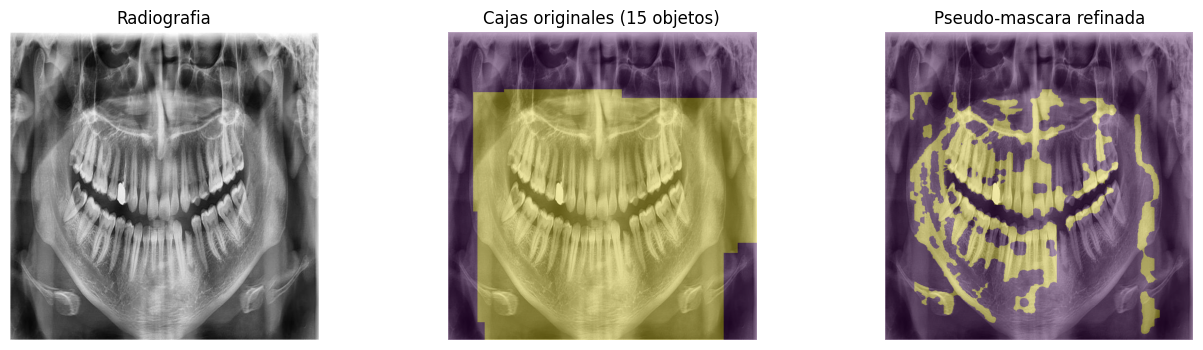

In [4]:
# Configuracion principal del experimento.
MASK_MODE = "binary"         # "binary" para diente/objeto vs fondo; "multiclass" para clases de hallazgos.
MASK_STRATEGY = "refined"   # "refined" usa imagen + caja; "box" usa rectangulos como baseline.
IMAGE_SIZE = (512, 256)      # (ancho, alto). Subir mejora detalle, pero consume mas memoria.
BATCH_SIZE = 32
NUM_WORKERS = 4

# False = entrenamiento completo con todos los registros encontrados.
# True = entrenamiento corto solo para probar que el flujo funciona.
QUICK_TEST = False
TRAIN_SAMPLE_LIMIT = 4000   # Baja/sube este valor segun el tiempo disponible.
VALID_SAMPLE_LIMIT = 800
MAX_TRAIN_SAMPLES = 500 if QUICK_TEST else TRAIN_SAMPLE_LIMIT
MAX_VALID_SAMPLES = 120 if QUICK_TEST else VALID_SAMPLE_LIMIT

train_records, train_classes = discover_records(DATASET_ROOTS, "train")
valid_records, valid_classes = discover_records(DATASET_ROOTS, "valid")

# Si no hay split de validacion, se separa desde train.
if not valid_records and len(train_records) >= 5:
    train_records, valid_records = train_test_split(train_records, test_size=0.15, random_state=SEED)

class_names = sorted({*train_classes, *valid_classes}, key=str.lower)

if MAX_TRAIN_SAMPLES:
    random.shuffle(train_records)
    train_records = train_records[:MAX_TRAIN_SAMPLES]
if MAX_VALID_SAMPLES:
    random.shuffle(valid_records)
    valid_records = valid_records[:MAX_VALID_SAMPLES]

print("Train records:", len(train_records))
print("Valid records:", len(valid_records))
print("Clases encontradas:", len(class_names))
print("Estrategia de mascara:", MASK_STRATEGY)
print("Quick test:", QUICK_TEST)
print(class_names[:60])

if not train_records:
    raise RuntimeError("No se encontraron anotaciones de entrenamiento. Revisa el arbol del dataset impreso arriba.")

train_ds = BoxMaskDataset(train_records, class_names, IMAGE_SIZE, MASK_MODE, augment=True, mask_strategy=MASK_STRATEGY)
valid_ds = BoxMaskDataset(valid_records, class_names, IMAGE_SIZE, MASK_MODE, augment=False, mask_strategy=MASK_STRATEGY)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}
if NUM_WORKERS > 0:
    loader_kwargs.update(persistent_workers=True, prefetch_factor=4)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs,
)
valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

print("Dataset listo.")
show_record(train_records[0], train_ds)

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class Up(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int) -> None:
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels // 2 + skip_channels, out_channels)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))

class UNetSmall(nn.Module):
    def __init__(self, in_channels: int = 1, out_channels: int = 1, base_channels: int = 16) -> None:
        super().__init__()
        c = base_channels
        self.inc = DoubleConv(in_channels, c)
        self.down1 = Down(c, c * 2)
        self.down2 = Down(c * 2, c * 4)
        self.down3 = Down(c * 4, c * 8)
        self.up1 = Up(c * 8, c * 4, c * 4)
        self.up2 = Up(c * 4, c * 2, c * 2)
        self.up3 = Up(c * 2, c, c)
        self.outc = nn.Conv2d(c, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        return self.outc(x)

def build_model(mask_mode: str, class_count: int, base_channels: int = 16) -> nn.Module:
    out_channels = 1 if mask_mode == "binary" else class_count + 1
    return UNetSmall(in_channels=1, out_channels=out_channels, base_channels=base_channels)

def binary_dice(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    pred = pred.reshape(pred.size(0), -1)
    target = target.reshape(target.size(0), -1)
    intersection = (pred * target).sum(dim=1)
    denominator = pred.sum(dim=1) + target.sum(dim=1)
    return ((2 * intersection + eps) / (denominator + eps)).mean()

def binary_iou(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    pred = pred.reshape(pred.size(0), -1)
    target = target.reshape(target.size(0), -1)
    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1) - intersection
    return ((intersection + eps) / (union + eps)).mean()

def compute_loss(logits: torch.Tensor, masks: torch.Tensor, mask_mode: str, criterion: nn.Module) -> torch.Tensor:
    if mask_mode == "binary":
        bce = criterion(logits, masks.float())
        dice = 1.0 - binary_dice(torch.sigmoid(logits), masks.float())
        return bce + dice
    return criterion(logits, masks.long())

In [6]:
BASE_CHANNELS = 16
EPOCHS = 3 if QUICK_TEST else 8
LEARNING_RATE = 1e-3
AMP = torch.cuda.is_available()
OUTPUT_DIR = RUN_DIR / f"{MASK_MODE}_{MASK_STRATEGY}_unet"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model = build_model(MASK_MODE, len(class_names), BASE_CHANNELS).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss() if MASK_MODE == "binary" else nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda", enabled=AMP)

def train_one_epoch() -> float:
    model.train()
    total_loss = 0.0
    total_items = 0
    for images, masks in tqdm(train_loader, desc="train", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP):
            logits = model(images)
            loss = compute_loss(logits, masks, MASK_MODE, criterion)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += float(loss.item()) * images.size(0)
        total_items += images.size(0)
    return total_loss / max(1, total_items)

@torch.no_grad()
def evaluate() -> tuple[float, dict[str, float]]:
    model.eval()
    total_loss = 0.0
    total_items = 0
    dice_values = []
    iou_values = []
    pixel_acc_values = []

    for images, masks in tqdm(valid_loader, desc="valid", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        logits = model(images)
        loss = compute_loss(logits, masks, MASK_MODE, criterion)
        total_loss += float(loss.item()) * images.size(0)
        total_items += images.size(0)

        if MASK_MODE == "binary":
            preds = (torch.sigmoid(logits) > 0.5).float()
            target = masks.float()
            dice_values.append(float(binary_dice(preds, target).item()))
            iou_values.append(float(binary_iou(preds, target).item()))
            pixel_acc_values.append(float((preds == target).float().mean().item()))
        else:
            preds = torch.argmax(logits, dim=1)
            target = masks.long()
            dice_values.append(float(binary_dice((preds > 0).float(), (target > 0).float()).item()))
            iou_values.append(float(binary_iou((preds > 0).float(), (target > 0).float()).item()))
            pixel_acc_values.append(float((preds == target).float().mean().item()))

    metrics = {
        "dice": float(np.mean(dice_values)) if dice_values else 0.0,
        "iou": float(np.mean(iou_values)) if iou_values else 0.0,
        "pixel_accuracy": float(np.mean(pixel_acc_values)) if pixel_acc_values else 0.0,
    }
    return total_loss / max(1, total_items), metrics

def save_checkpoint(path: Path, best_score: float) -> None:
    torch.save(
        {
            "model_state": model.state_dict(),
            "class_names": class_names,
            "mask_mode": MASK_MODE,
            "mask_strategy": MASK_STRATEGY,
            "image_size": IMAGE_SIZE,
            "base_channels": BASE_CHANNELS,
            "best_score": best_score,
            "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        },
        path,
    )

best_score = -1.0
history = []
print(f"Entrenando por {EPOCHS} epocas en {DEVICE}. Salida: {OUTPUT_DIR}")

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    valid_loss, metrics = evaluate()
    score = metrics["dice"]
    row = {"epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss, **metrics}
    history.append(row)
    print(
        f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | "
        f"dice={metrics['dice']:.4f} | iou={metrics['iou']:.4f} | pixel_acc={metrics['pixel_accuracy']:.4f}"
    )
    if score > best_score:
        best_score = score
        save_checkpoint(OUTPUT_DIR / "best_model.pt", best_score)

save_checkpoint(OUTPUT_DIR / "last_model.pt", best_score)
(OUTPUT_DIR / "history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")
print("Mejor Dice:", best_score)
print("Checkpoint:", OUTPUT_DIR / "best_model.pt")

Entrenando por 8 epocas en cuda. Salida: /content/dental_cnn_runs/binary_refined_unet


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train:   0%|          | 0/125 [00:00<?, ?it/s]

valid:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | train_loss=1.0382 | valid_loss=0.9560 | dice=0.5992 | iou=0.4525 | pixel_acc=0.8070


...

valid:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 007 | train_loss=0.6792 | valid_loss=0.7656 | dice=0.6460 | iou=0.5003 | pixel_acc=0.8455


train:   0%|          | 0/125 [00:00<?, ?it/s]

valid:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 008 | train_loss=0.6680 | valid_loss=0.7307 | dice=0.6536 | iou=0.5064 | pixel_acc=0.8529
Mejor Dice: 0.6536003088951111
Checkpoint: /content/dental_cnn_runs/binary_refined_unet/best_model.pt


In [7]:
@dataclass
class Instance:
    label: str
    class_name: str
    mask: np.ndarray

    bbox: tuple[int, int, int, int]
    area: int
    score: float

PALETTE = np.array(
    [
        [230, 57, 70], [42, 157, 143], [244, 162, 97], [69, 123, 157],
        [131, 56, 236], [255, 183, 3], [6, 214, 160], [239, 71, 111],
        [17, 138, 178], [255, 209, 102], [58, 134, 255], [128, 237, 153],
    ],
    dtype=np.uint8,
)

def clean_binary_mask(mask: np.ndarray, min_area: int = 120) -> np.ndarray:
    mask = (mask > 0).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for component_id in range(1, num):
        area = int(stats[component_id, cv2.CC_STAT_AREA])
        if area >= min_area:
            cleaned[labels == component_id] = 1
    return cleaned

def components_to_instances(
    mask: np.ndarray,
    class_name: str = "Tooth",
    probabilities: np.ndarray | None = None,
    min_area: int = 120,
) -> list[Instance]:
    clean = clean_binary_mask(mask, min_area=min_area)
    num, labels, stats, _ = cv2.connectedComponentsWithStats(clean, connectivity=8)
    instances = []
    for component_id in range(1, num):
        area = int(stats[component_id, cv2.CC_STAT_AREA])
        if area < min_area:
            continue
        x = int(stats[component_id, cv2.CC_STAT_LEFT])
        y = int(stats[component_id, cv2.CC_STAT_TOP])
        w = int(stats[component_id, cv2.CC_STAT_WIDTH])
        h = int(stats[component_id, cv2.CC_STAT_HEIGHT])
        component_mask = (labels == component_id).astype(np.uint8)
        score = float(probabilities[component_mask > 0].mean()) if probabilities is not None else 1.0
        instances.append(Instance("", class_name, component_mask, (x, y, x + w, y + h), area, score))
    return assign_tooth_labels(instances)

def assign_tooth_labels(instances: list[Instance], style: str = "fdi") -> list[Instance]:
    if not instances:
        return []
    centers_y = np.array([(inst.bbox[1] + inst.bbox[3]) / 2 for inst in instances], dtype=np.float32)
    jaw_cut = float(np.median(centers_y))
    upper = [inst for inst in instances if (inst.bbox[1] + inst.bbox[3]) / 2 <= jaw_cut]
    upper_ids = {id(inst) for inst in upper}
    lower = [inst for inst in instances if id(inst) not in upper_ids]
    upper.sort(key=lambda inst: (inst.bbox[0] + inst.bbox[2]) / 2)
    lower.sort(key=lambda inst: (inst.bbox[0] + inst.bbox[2]) / 2)

    if style == "fdi":
        upper_codes = [18, 17, 16, 15, 14, 13, 12, 11, 21, 22, 23, 24, 25, 26, 27, 28]
        lower_codes = [48, 47, 46, 45, 44, 43, 42, 41, 31, 32, 33, 34, 35, 36, 37, 38]
        for inst, code in zip(upper, fit_codes(upper_codes, len(upper))):
            inst.label = str(code)
        for inst, code in zip(lower, fit_codes(lower_codes, len(lower))):
            inst.label = str(code)
    else:
        for idx, inst in enumerate(upper + lower, start=1):
            inst.label = f"T{idx:02d}"
    return sorted(upper + lower, key=lambda inst: (inst.bbox[1], inst.bbox[0]))

def fit_codes(codes: list[int], count: int) -> list[int]:
    if count <= len(codes):
        start = max(0, (len(codes) - count) // 2)
        return codes[start : start + count]
    return codes + list(range(1, count - len(codes) + 1))

def put_label(image: np.ndarray, text: str, x: int, y: int, color_bgr: tuple[int, int, int]) -> None:
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.48
    thickness = 1
    (w, h), baseline = cv2.getTextSize(text, font, scale, thickness)
    y = max(h + baseline + 3, y)
    x = max(0, min(x, image.shape[1] - w - 6))
    cv2.rectangle(image, (x, y - h - baseline - 4), (x + w + 6, y + baseline + 2), (0, 0, 0), -1)
    cv2.putText(image, text, (x + 3, y - 2), font, scale, color_bgr, thickness, cv2.LINE_AA)

def draw_instances(image_path: Path, instances: list[Instance], output_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(image_path)
    overlay = image.copy()
    for idx, inst in enumerate(instances):
        color = tuple(int(v) for v in PALETTE[idx % len(PALETTE)])
        color_bgr = (color[2], color[1], color[0])
        overlay[inst.mask > 0] = (0.55 * overlay[inst.mask > 0] + 0.45 * np.array(color_bgr)).astype(np.uint8)
        contours, _ = cv2.findContours(inst.mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, color_bgr, 2)
        x1, y1, x2, y2 = inst.bbox
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color_bgr, 1)
        text = inst.label if inst.class_name == "Tooth" else f"{inst.label}:{inst.class_name}"
        put_label(overlay, text, x1, max(0, y1 - 6), color_bgr)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), overlay)
    return overlay

def instances_to_json(instances: list[Instance], path: Path) -> None:
    payload = [
        {
            "label": inst.label,
            "class_name": inst.class_name,
            "bbox": list(inst.bbox),
            "area": inst.area,
            "score": round(inst.score, 4),
        }
        for inst in instances
    ]
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

Imagen guardada: /content/dental_cnn_runs/predictions/demo_rotulada.png
JSON guardado: /content/dental_cnn_runs/predictions/demo_rotulada.json
Instancias detectadas: 7


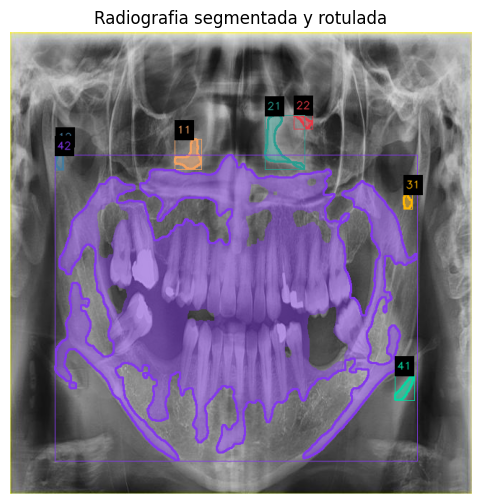

In [8]:
def preprocess_for_model(image: np.ndarray, image_size: tuple[int, int]) -> torch.Tensor:
    width, height = image_size
    resized = cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)
    resized = resized.astype(np.float32) / 255.0
    resized = (resized - 0.5) / 0.5
    return torch.from_numpy(resized[None, None, :, :]).float()

@torch.no_grad()
def predict_radiograph(
    image_path: Path,
    checkpoint_path: Path,
    output_path: Path,
    threshold: float = 0.5,
    min_area: int = 160,
    label_style: str = "fdi",
) -> list[Instance]:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    ckpt_class_names = checkpoint["class_names"]
    ckpt_mask_mode = checkpoint["mask_mode"]
    ckpt_image_size = tuple(checkpoint["image_size"])
    ckpt_base_channels = int(checkpoint.get("base_channels", 16))

    pred_model = build_model(ckpt_mask_mode, len(ckpt_class_names), ckpt_base_channels).to(DEVICE)
    pred_model.load_state_dict(checkpoint["model_state"])
    pred_model.eval()

    original = load_grayscale(image_path)
    model_input = preprocess_for_model(original, ckpt_image_size).to(DEVICE)
    logits = pred_model(model_input)[0].cpu()

    if ckpt_mask_mode == "binary":
        prob_small = torch.sigmoid(logits[0]).numpy()
        prob = cv2.resize(prob_small, (original.shape[1], original.shape[0]), interpolation=cv2.INTER_LINEAR)
        mask = (prob >= threshold).astype(np.uint8)
        instances = components_to_instances(mask, "Tooth", prob, min_area=min_area)
    else:
        probs_small = torch.softmax(logits, dim=0).numpy()
        class_map_small = np.argmax(probs_small, axis=0).astype(np.uint8)
        class_map = cv2.resize(class_map_small, (original.shape[1], original.shape[0]), interpolation=cv2.INTER_NEAREST)
        confident = cv2.resize(np.max(probs_small, axis=0), (original.shape[1], original.shape[0]), interpolation=cv2.INTER_LINEAR) >= threshold
        class_map = np.where(confident, class_map, 0).astype(np.uint8)
        instances = []
        for class_id, class_name in enumerate(ckpt_class_names, start=1):
            mask = (class_map == class_id).astype(np.uint8)
            instances.extend(components_to_instances(mask, class_name, None, min_area=min_area))

    instances = assign_tooth_labels(instances, style=label_style)
    overlay = draw_instances(image_path, instances, output_path)
    instances_to_json(instances, output_path.with_suffix(".json"))

    print("Imagen guardada:", output_path)
    print("JSON guardado:", output_path.with_suffix(".json"))
    print("Instancias detectadas:", len(instances))

    plt.figure(figsize=(14, 6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Radiografia segmentada y rotulada")
    plt.show()
    return instances

# Prediccion de demostracion sobre una imagen de validacion.
checkpoint_path = OUTPUT_DIR / "best_model.pt"
demo_image = valid_records[0].image_path if valid_records else train_records[0].image_path
demo_output = RUN_DIR / "predictions" / "demo_rotulada.png"
instances = predict_radiograph(demo_image, checkpoint_path, demo_output, threshold=0.5, min_area=160, label_style="fdi")

In [9]:
# Opcional: subir una radiografia propia y generar salida rotulada.
# Cambia RUN_UPLOAD_DEMO a True cuando quieras probar con una imagen externa.
RUN_UPLOAD_DEMO = False

if RUN_UPLOAD_DEMO:
    from google.colab import files

    uploaded = files.upload()
    for name, content in uploaded.items():
        input_path = Path("/content") / name
        input_path.write_bytes(content)
        output_path = RUN_DIR / "predictions" / f"{input_path.stem}_rotulada.png"
        predict_radiograph(
            image_path=input_path,
            checkpoint_path=OUTPUT_DIR / "best_model.pt",
            output_path=output_path,
            threshold=0.5,
            min_area=160,
            label_style="fdi",
        )
else:
    print("Carga manual desactivada. Cambia RUN_UPLOAD_DEMO = True para probar una radiografia propia.")

Carga manual desactivada. Cambia RUN_UPLOAD_DEMO = True para probar una radiografia propia.
